# Stillwater 4-Tetromino Project Sibling

This notebook creates a compact SewerTris sibling from `example_02_Stillwater_sewertris_project.ipynb`. The base project already defines the Stillwater domain, modeling parameters, SWMM options, and scenario settings. Here we declare the change: use the four-tetromino set `I_O_T_S_only`, increase the cell size, and modify the land use distribution.

`clone_sibling(...)` copies only the reusable artifacts from the parent project. Because the tetromino set, cell size and the land use distribution change the urban layout, the sibling reuses the domain artifacts and reruns the dependent physical and SWMM workflow using the parameters recorded in the parent project manifest.


## Setup

Load the refactored package and the completed Example 02 project. If you are editing package code while working in this notebook, rerunning this cell reloads the local modules.


In [1]:
from pathlib import Path
import importlib
import sys

import geopandas as gpd
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "sewertris").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXAMPLES_DIR = PROJECT_ROOT / "Examples"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import sewertris

for _module_name in [
    "sewertris._deps",
    "sewertris.domain",
    "sewertris.layout",
    "sewertris.roads",
    "sewertris.topography",
    "sewertris.sewer_network",
    "sewertris.hydrology",
    "sewertris.design",
    "sewertris.swmm",
    "sewertris.plots",
    "sewertris.project",
    "sewertris",
]:
    if _module_name in sys.modules:
        importlib.reload(sys.modules[_module_name])

import sewertris as st

base_project_path = EXAMPLES_DIR / "output_example_2_project"

base_project = st.SewerTrisProject.load(base_project_path)
print("Base project:", base_project.project_file)


Base project: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewertris_project.json


## Clone Sibling

Create the sibling project and record its lineage. The only model change is the tetromino set. The clone keeps the parent domain files and marks the workflow to rerun from the tetromino/layout stage onward.


In [2]:
changes = {
    "tetromino_set": "I_O_T_S_only",
    "cell_size_m": 200,
    "land_use_distribution": {
        'RESIDENTIAL': 0.2,
        'COMMERCIAL':  0.6,
        'INDUSTRIAL':  0.15,
        'PUBLIC':      0.1,
        'RECREATIONAL':0.05
    },
}

project = base_project.clone_sibling(
    EXAMPLES_DIR / "output_example_3_project",
    name="Stillwater 4-Tetromino SewerTris Project",
    changes=changes,
)

print("Sibling project:", project.project_file)
print("Rerun from:", project.metadata["lineage"]["rerun_from"])
print("Copied artifacts:", project.metadata["lineage"]["copied_artifacts"])


Sibling project: /Users/kevinblanco/Documents/Sewertris/examples/output_example_3_project/sewertris_project.json
Rerun from: 01_urban_domain_definition
Copied artifacts: {}


## Run Sibling

Rerun the dependent workflow using parameters from the parent project. This call regenerates the layout, roads, land use, DEM, sewer network, flow predesign, pipe design, base SWMM file, and named SWMM scenario.


✅ Exported 410 figures to /Users/kevinblanco/Documents/Sewertris/examples/output_example_3_project/city_layout.gpkg
[OK] Boundary lines written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_3_project/road_boundary_lines.gpkg
[OK] Outer shell polygon(s) written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_3_project/road_outer_shell.gpkg
✅ Exported to /Users/kevinblanco/Documents/Sewertris/examples/output_example_3_project/city_blocks.gpkg
Original boundary CRS: EPSG:32614
Original roads CRS: EPSG:32614

Boundary extent:
X range: 667166.00 to 678576.00
Y range: 3994829.67 to 4006639.67
Boundary CRS: EPSG:32614
Boundary bounds: [ 667165.9958307  3994829.67323194  678575.9958307  4006639.67323194]
Grid shape: (1202, 1162)
Grid extent:
  X: 667060.00 to 678680.00
  Y: 3994720.00 to 4006740.00
Creating mask...
Processing row 0 of 1202
Processing row 100 of 1202
Processing row 200 of 1202
Processing row 300 of 1202
Processing row 400 of 1202
Processi

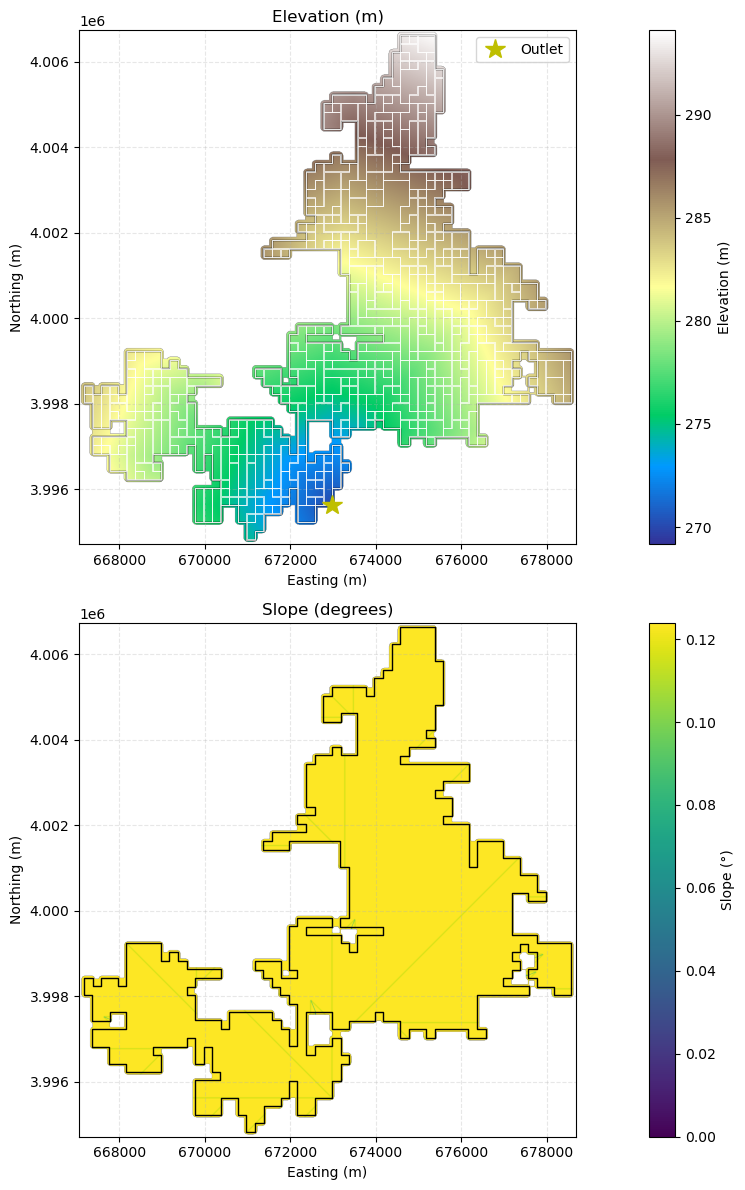


Terrain Statistics:
Elevation range: 269.17m - 294.09m
Mean elevation: 281.10m
Mean slope: 0.12°
Max slope: 2.50°

Drainage Statistics:
Points with proper drainage: 500309.0 out of 533617 (93.8%)
✅ Extracted 979 manholes from road centerlines.
✅ Manholes exported to /Users/kevinblanco/Documents/Sewertris/examples/output_example_3_project/manholes.gpkg

Path Statistics:
Head: MH177  →  Target: MH485
Segments: 63
Total length: 15400.0 m
Total drop: 24.82 m
Avg slope: 0.160%
⚠️ Some manholes could not be connected while preserving constraints.
✅ Generated 262 secondary pipes.
✅ Cleaned: 0 secondary pipes removed.
📊 V2 initial missing outlet pipes: 653
V2 iteration 1: start=MH015, status=committed, chain_len=13, cost=2699.41, remaining=640
V2 iteration 2: start=MH018, status=committed, chain_len=10, cost=2511.96, remaining=630
V2 iteration 3: start=MH023, status=committed, chain_len=13, cost=3144.61, remaining=617
V2 iteration 4: start=MH025, status=committed, chain_len=4, cost=946.27, re

In [3]:
results = project.rerun_from_parent_parameters(
    base_project,
)

scenario = results["scenario"]
df = results["flow_components"]

print("Sibling metadata:", project.project_file)
print("Scenario input:", scenario.swmm_inp_path)
print("Flow components:", scenario.flows_path)


## Review Outputs

Use the standard plots to inspect the sibling. These are optional diagnostics; the model artifacts and lineage are already saved in `output_example_3_project`.


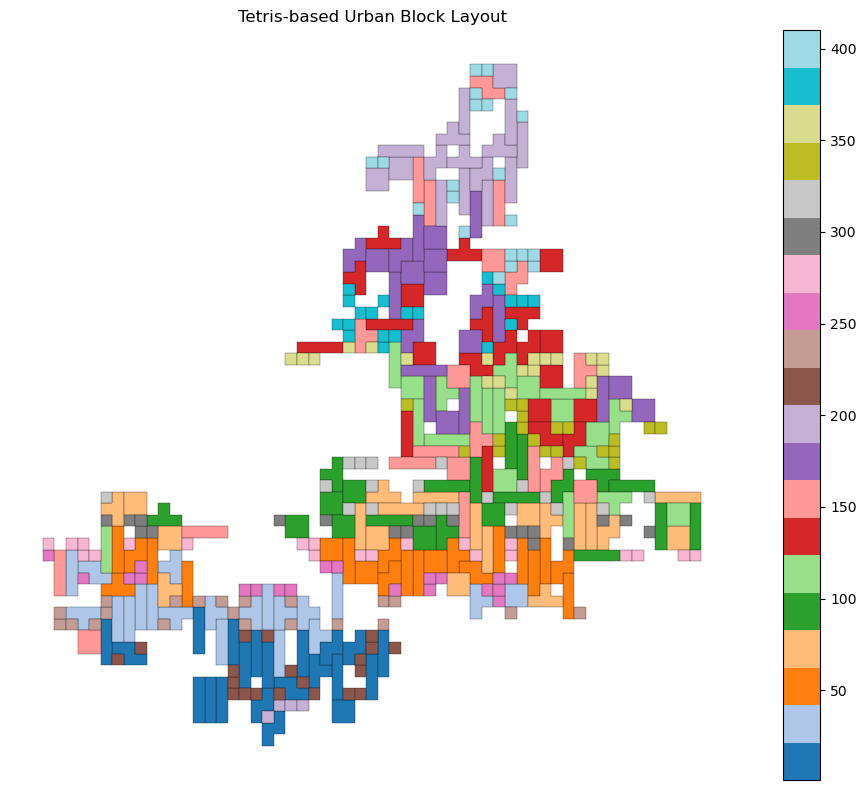

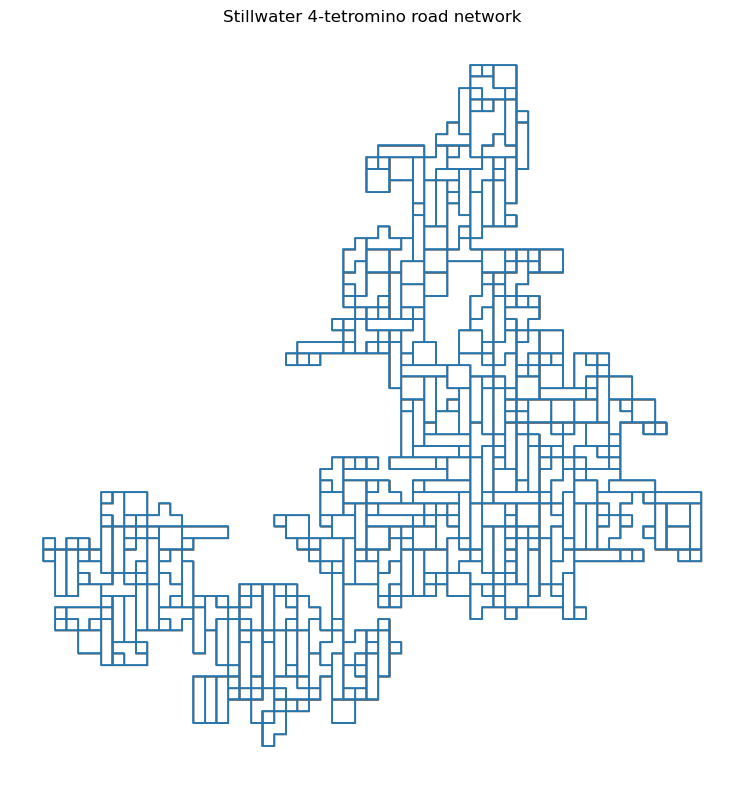

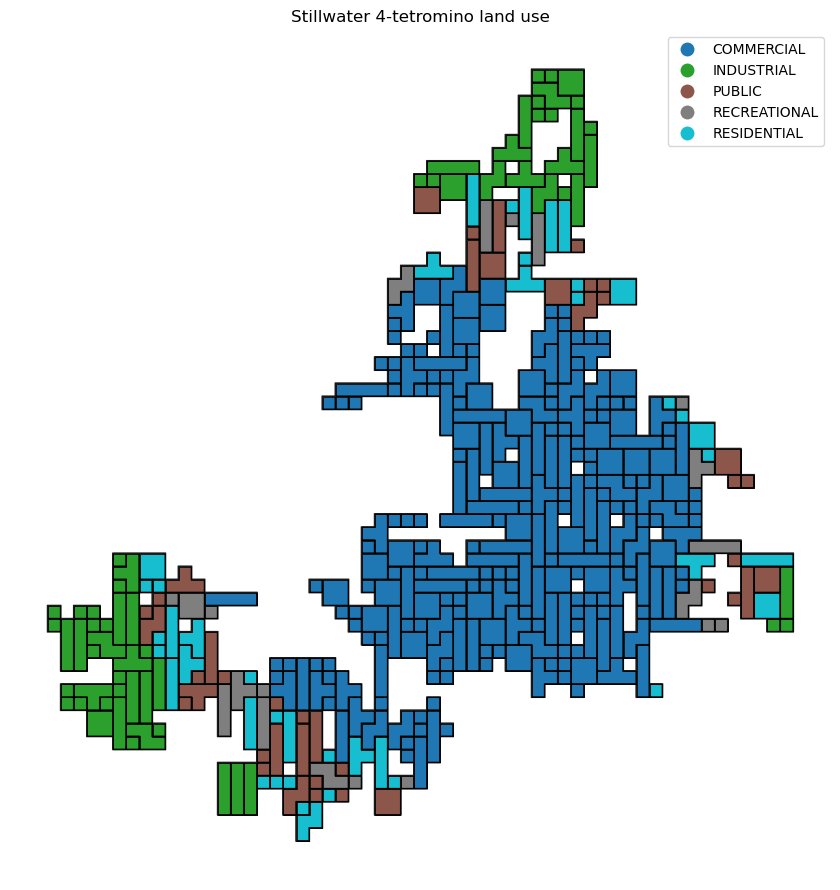

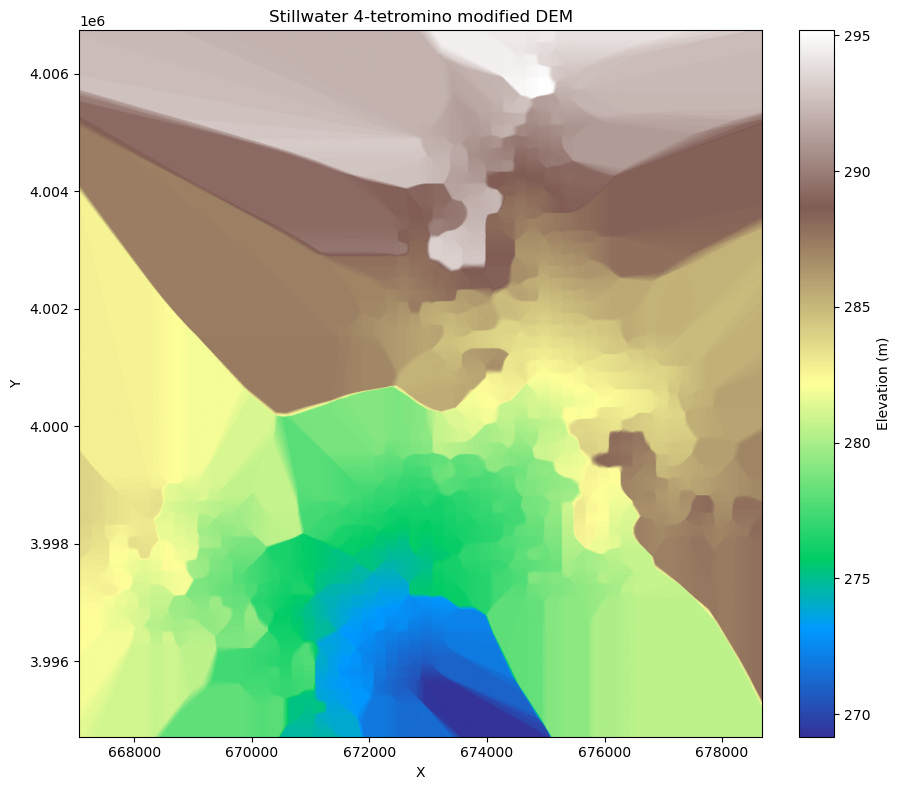

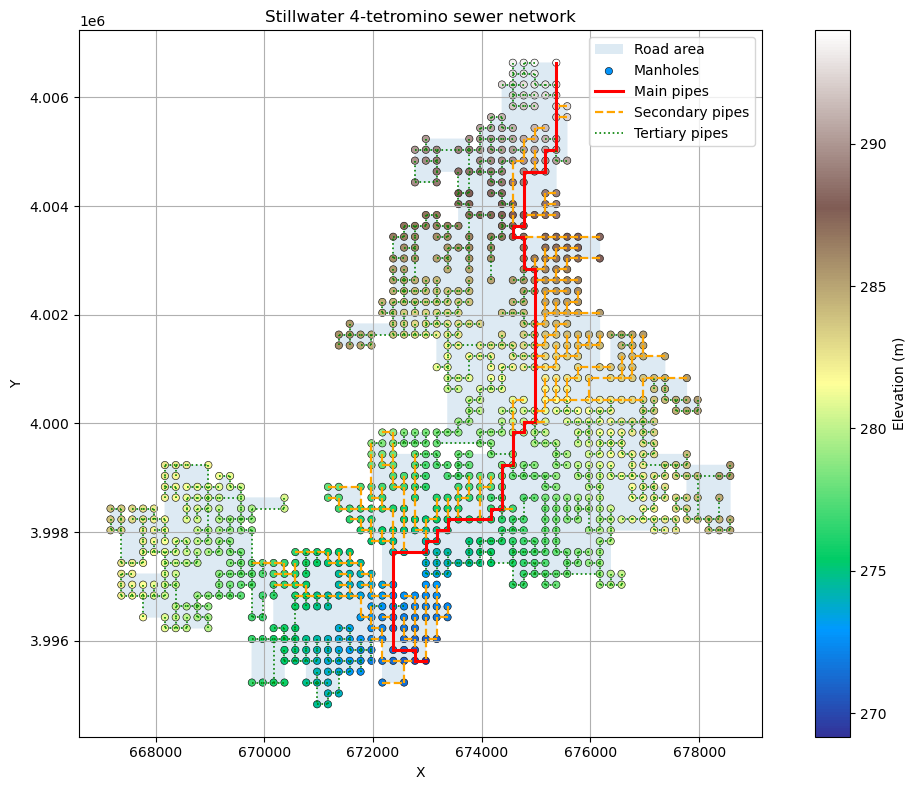

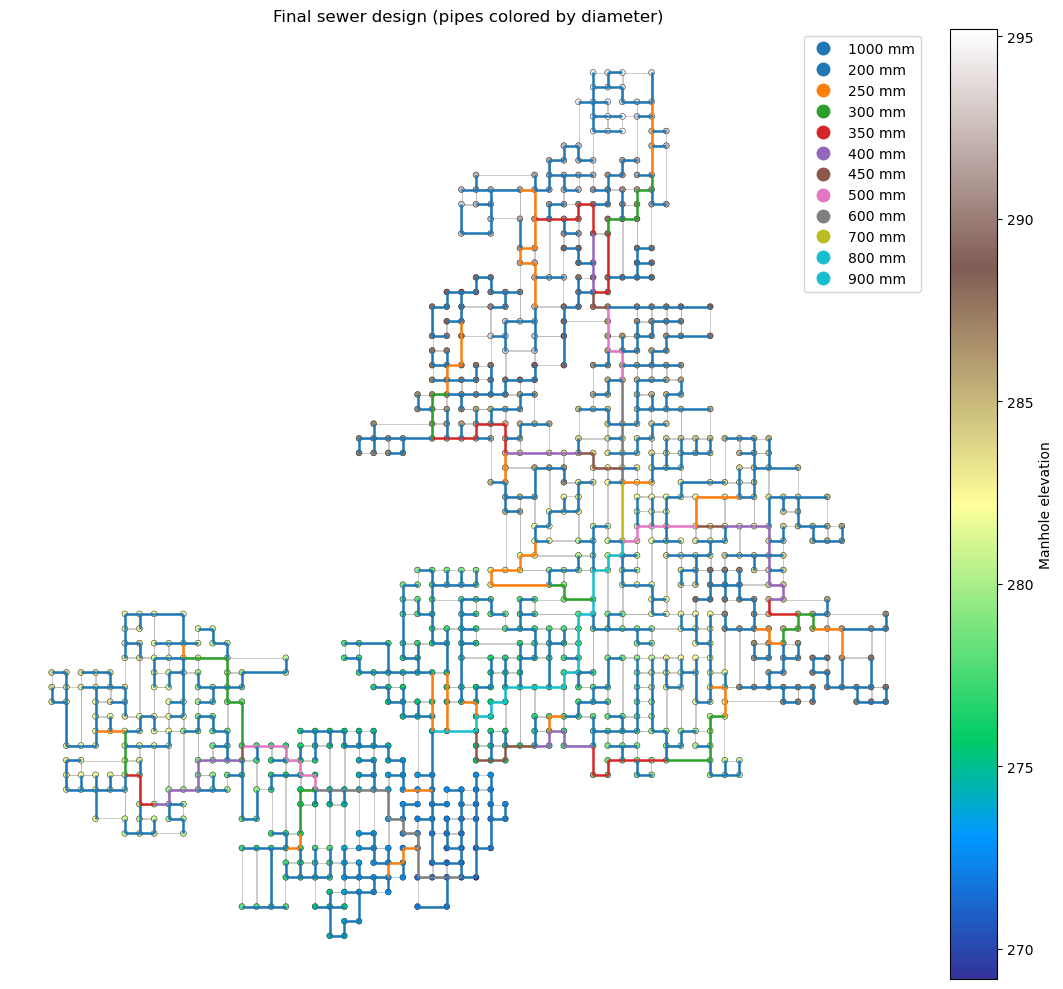

In [4]:
st.plot_filled_board_shapefile(project.layout_blocks_path)

st.plot_roads(
    road_lines=results["road_lines"],
    road_buffer=results["road_buffer"],
    crs=results["crs"],
    title="Stillwater 4-tetromino road network",
)

roads_gdf = gpd.read_file(project.road_polygons_path)
blocks_gdf = gpd.read_file(project.blocks_path)
if roads_gdf.crs != blocks_gdf.crs:
    roads_gdf = roads_gdf.to_crs(blocks_gdf.crs)
st.plot_blocks_landuse(
    blocks_gdf=blocks_gdf,
    roads_gdf=roads_gdf,
    landuse_col="land_use",
    title="Stillwater 4-tetromino land use",
)

st.plot_dem_tif(project.dem_path, title="Stillwater 4-tetromino modified DEM", hillshade=False)

st.plot_sewer_network_all(
    manholes=project.state["manholes"],
    main_pipes=project.state["main_path"],
    secondary_pipes=project.state["secondary_pipes"],
    tertiary_pipes=project.state["tertiary_pipes"],
    unresolved=project.state["tertiary_unconnected"],
    road_buffer=project.state["road_buffer"],
    title="Stillwater 4-tetromino sewer network",
)

st.plot_final_design_color_by_diameter(
    pipes_path=project.pipes_path,
    manholes_path=project.manholes_path,
    blocks_path=project.blocks_path,
    diameter_field="diameter_mm",
    manhole_color_field="elevation",
    linewidth=1.8,
)


## Flow Decomposition

Plot and save the sibling flow components using the parent simulation dates recorded in the SWMM options.


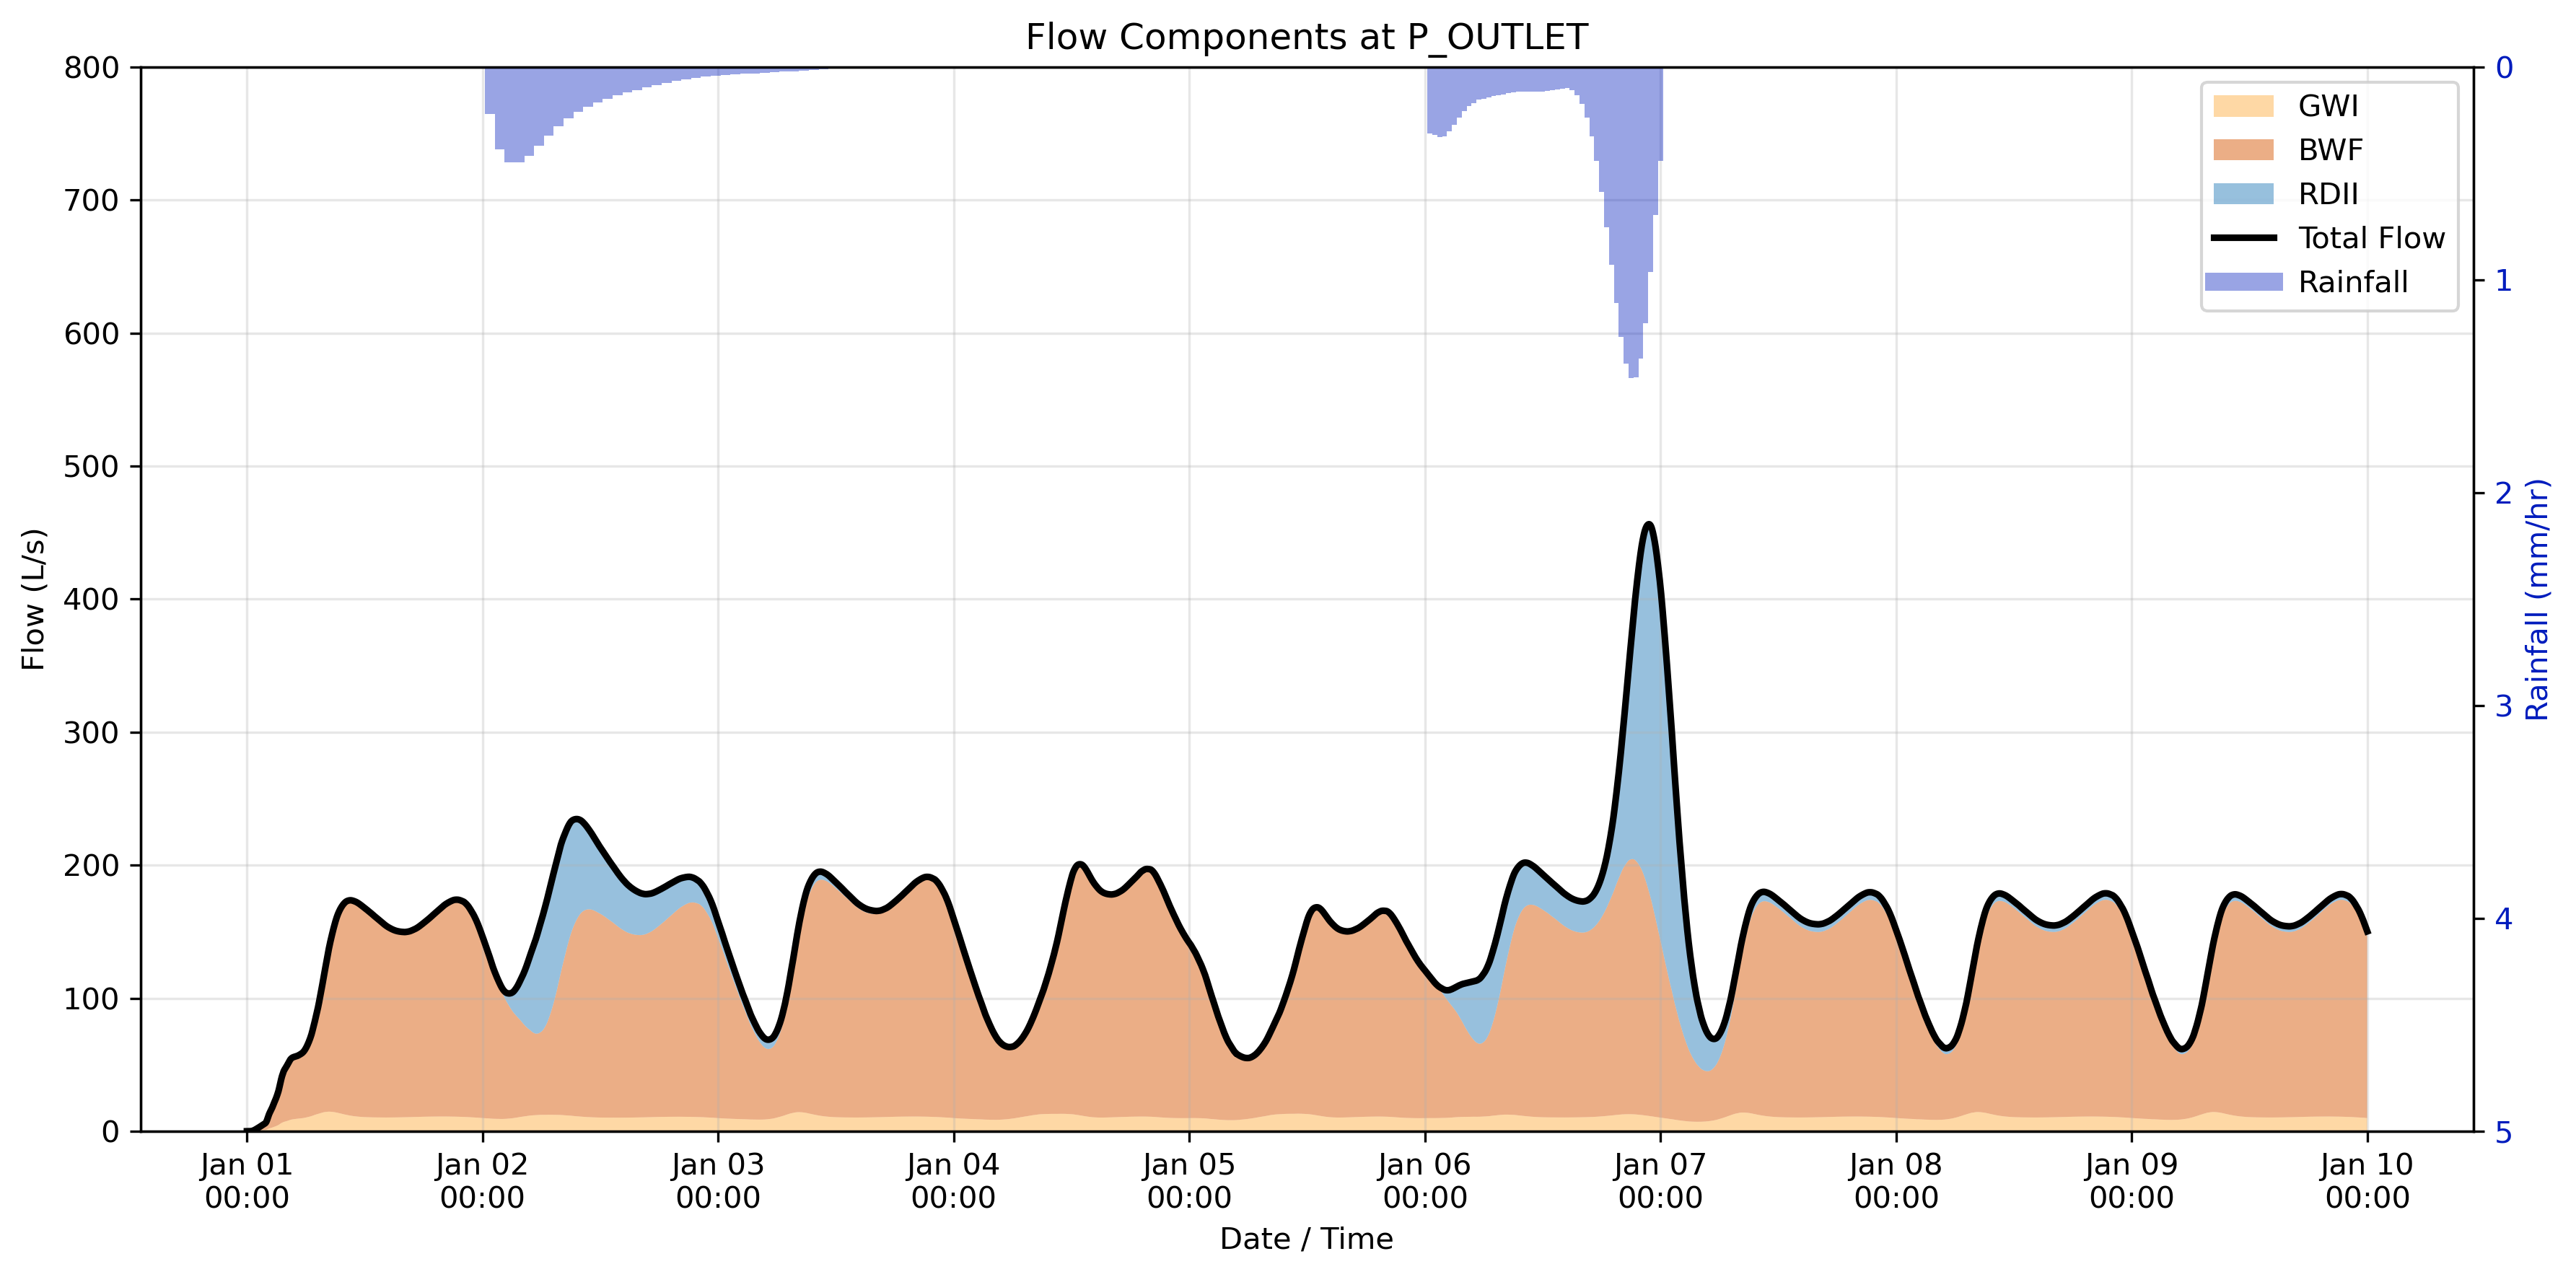

Project metadata: /Users/kevinblanco/Documents/Sewertris/examples/output_example_3_project/sewertris_project.json
Parent project: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewertris_project.json


In [5]:
options = base_project.step_parameters("10_dynamic_flow_input_definition_base_model").get("options_dict", {})
start = f"{options.get('START_DATE', '01/01/1990')} {options.get('START_TIME', '00:00:00')}"
end = f"{options.get('END_DATE', '01/10/1990')} {options.get('END_TIME', '00:00:00')}"

rainfall_data=[
    ('1/2/2025', '00:00', 0.0), ('1/2/2025', '00:30', 0.2205), ('1/2/2025', '01:00', 0.2205),
    ('1/2/2025', '01:30', 0.3855), ('1/2/2025', '02:00', 0.3855), ('1/2/2025', '02:30', 0.447),
    ('1/2/2025', '03:00', 0.447), ('1/2/2025', '03:30', 0.447), ('1/2/2025', '04:00', 0.447),
    ('1/2/2025', '04:30', 0.4155), ('1/2/2025', '05:00', 0.4155), ('1/2/2025', '05:30', 0.3705),
    ('1/2/2025', '06:00', 0.3705), ('1/2/2025', '06:30', 0.3235), ('1/2/2025', '07:00', 0.3235),
    ('1/2/2025', '07:30', 0.2795), ('1/2/2025', '08:00', 0.2795), ('1/2/2025', '08:30', 0.242),
    ('1/2/2025', '09:00', 0.242), ('1/2/2025', '09:30', 0.211), ('1/2/2025', '10:00', 0.211),
    ('1/2/2025', '10:30', 0.186), ('1/2/2025', '11:00', 0.186), ('1/2/2025', '11:30', 0.1655),
    ('1/2/2025', '12:00', 0.1655), ('1/2/2025', '12:30', 0.148), ('1/2/2025', '13:00', 0.148),
    ('1/2/2025', '13:30', 0.133), ('1/2/2025', '14:00', 0.133), ('1/2/2025', '14:30', 0.12),
    ('1/2/2025', '15:00', 0.12), ('1/2/2025', '15:30', 0.1075), ('1/2/2025', '16:00', 0.1075),
    ('1/2/2025', '16:30', 0.0955), ('1/2/2025', '17:00', 0.0955), ('1/2/2025', '17:30', 0.085),
    ('1/2/2025', '18:00', 0.085), ('1/2/2025', '18:30', 0.0745), ('1/2/2025', '19:00', 0.0745),
    ('1/2/2025', '19:30', 0.0655), ('1/2/2025', '20:00', 0.0655), ('1/2/2025', '20:30', 0.0575),
    ('1/2/2025', '21:00', 0.0575), ('1/2/2025', '21:30', 0.0505), ('1/2/2025', '22:00', 0.0505),
    ('1/2/2025', '22:30', 0.045), ('1/2/2025', '23:00', 0.045), ('1/2/2025', '23:30', 0.0405),
    ('1/3/2025', '00:00', 0.0405), ('1/3/2025', '00:30', 0.0365), ('1/3/2025', '01:00', 0.0365),
    ('1/3/2025', '01:30', 0.034), ('1/3/2025', '02:00', 0.034), ('1/3/2025', '02:30', 0.031),
    ('1/3/2025', '03:00', 0.031), ('1/3/2025', '03:30', 0.0295), ('1/3/2025', '04:00', 0.0295),
    ('1/3/2025', '04:30', 0.027), ('1/3/2025', '05:00', 0.027), ('1/3/2025', '05:30', 0.025),
    ('1/3/2025', '06:00', 0.025), ('1/3/2025', '06:30', 0.022), ('1/3/2025', '07:00', 0.022),
    ('1/3/2025', '07:30', 0.0195), ('1/3/2025', '08:00', 0.0195), ('1/3/2025', '08:30', 0.0165),
    ('1/3/2025', '09:00', 0.0165), ('1/3/2025', '09:30', 0.0135), ('1/3/2025', '10:00', 0.0135),
    ('1/3/2025', '10:30', 0.01), ('1/3/2025', '11:00', 0.01), ('1/3/2025', '11:30', 0.0075),
    ('1/3/2025', '12:00', 0.0075), ('1/3/2025', '12:30', 0.005), ('1/3/2025', '13:00', 0.005),
    ('1/3/2025', '13:30', 0.003), ('1/3/2025', '14:00', 0.003), ('1/3/2025', '14:30', 0.002),
    ('1/3/2025', '15:00', 0.002), ('1/3/2025', '15:30', 0.0005), ('1/3/2025', '16:00', 0.0005),
    ('1/3/2025', '16:30', 0.0), ('1/3/2025', '17:00', 0.0), ('1/3/2025', '17:30', 0.0005),
    ('1/3/2025', '18:00', 0.0005), ('1/3/2025', '18:30', 0.0), ('1/3/2025', '19:00', 0.0),
    ('1/3/2025', '19:30', 0.0), ('1/3/2025', '20:00', 0.0), ('1/3/2025', '20:30', 0.0),
    ('1/3/2025', '21:00', 0.0005), ('1/3/2025', '21:30', 0.0005), ('1/3/2025', '22:00', 0.0005),
    ('1/3/2025', '22:30', 0.0005), ('1/3/2025', '23:00', 0.0), ('1/3/2025', '23:30', 0.0),
    ('1/4/2025', '00:00', 0.0), ('1/4/2025', '00:30', 0.0), ('1/4/2025', '01:00', 0.0),
    ('1/6/2025', '00:00', 0.0), ('1/6/2025', '00:30', 0.312), ('1/6/2025', '01:00', 0.32),
    ('1/6/2025', '01:30', 0.33), ('1/6/2025', '02:00', 0.324), ('1/6/2025', '02:30', 0.302),
    ('1/6/2025', '03:00', 0.27), ('1/6/2025', '03:30', 0.238), ('1/6/2025', '04:00', 0.208),
    ('1/6/2025', '04:30', 0.184), ('1/6/2025', '05:00', 0.168), ('1/6/2025', '05:30', 0.154),
    ('1/6/2025', '06:00', 0.148), ('1/6/2025', '06:30', 0.142), ('1/6/2025', '07:00', 0.136),
    ('1/6/2025', '07:30', 0.132), ('1/6/2025', '08:00', 0.128), ('1/6/2025', '08:30', 0.122),
    ('1/6/2025', '09:00', 0.12), ('1/6/2025', '09:30', 0.116), ('1/6/2025', '10:00', 0.114),
    ('1/6/2025', '10:30', 0.116), ('1/6/2025', '11:00', 0.116), ('1/6/2025', '11:30', 0.114),
    ('1/6/2025', '12:00', 0.116), ('1/6/2025', '12:30', 0.112), ('1/6/2025', '13:00', 0.11),
    ('1/6/2025', '13:30', 0.104), ('1/6/2025', '14:00', 0.102), ('1/6/2025', '14:30', 0.1),
    ('1/6/2025', '15:00', 0.11), ('1/6/2025', '15:30', 0.132), ('1/6/2025', '16:00', 0.172),
    ('1/6/2025', '16:30', 0.236), ('1/6/2025', '17:00', 0.324), ('1/6/2025', '17:30', 0.442),
    ('1/6/2025', '18:00', 0.586), ('1/6/2025', '18:30', 0.754), ('1/6/2025', '19:00', 0.93),
    ('1/6/2025', '19:30', 1.11), ('1/6/2025', '20:00', 1.268), ('1/6/2025', '20:30', 1.392),
    ('1/6/2025', '21:00', 1.46), ('1/6/2025', '21:30', 1.456), ('1/6/2025', '22:00', 1.37),
    ('1/6/2025', '22:30', 1.202), ('1/6/2025', '23:00', 0.964), ('1/6/2025', '23:30', 0.694),
    ('1/7/2025', '00:00', 0.44), ('1/7/2025', '00:30', 0.0), ('1/7/2025', '01:00', 0.0),          
]

st.plot_flow_components_v2(
    df,
    rain=rainfall_data,
    start=start, end=end,
    flow_units="L/s",
    stack_components=True,
    flow_min=0,
    flow_max=800,
    rain_min=0,
    rain_max=5)
project.save()
print("Project metadata:", project.project_file)
print("Parent project:", project.metadata["lineage"]["parent_project_file"])


## Compare Base vs Sibling

Create side-by-side comparison plots between the original Stillwater project and the 4-tetromino sibling. The comparison reads the completed project artifacts directly, so no model inputs need to be redefined here.


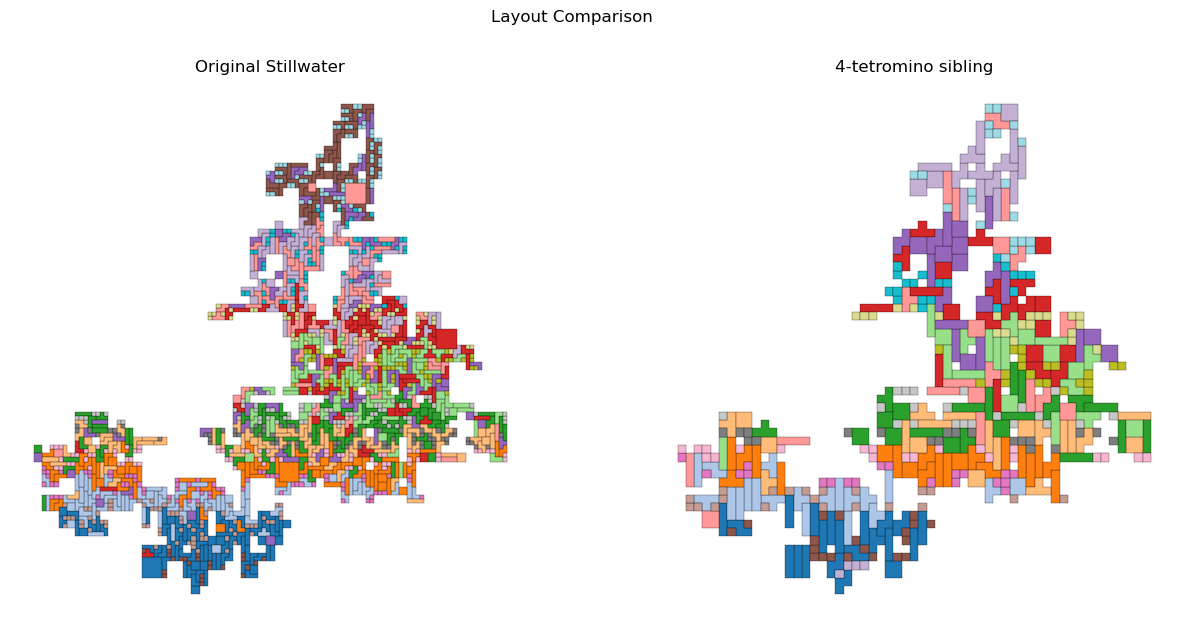

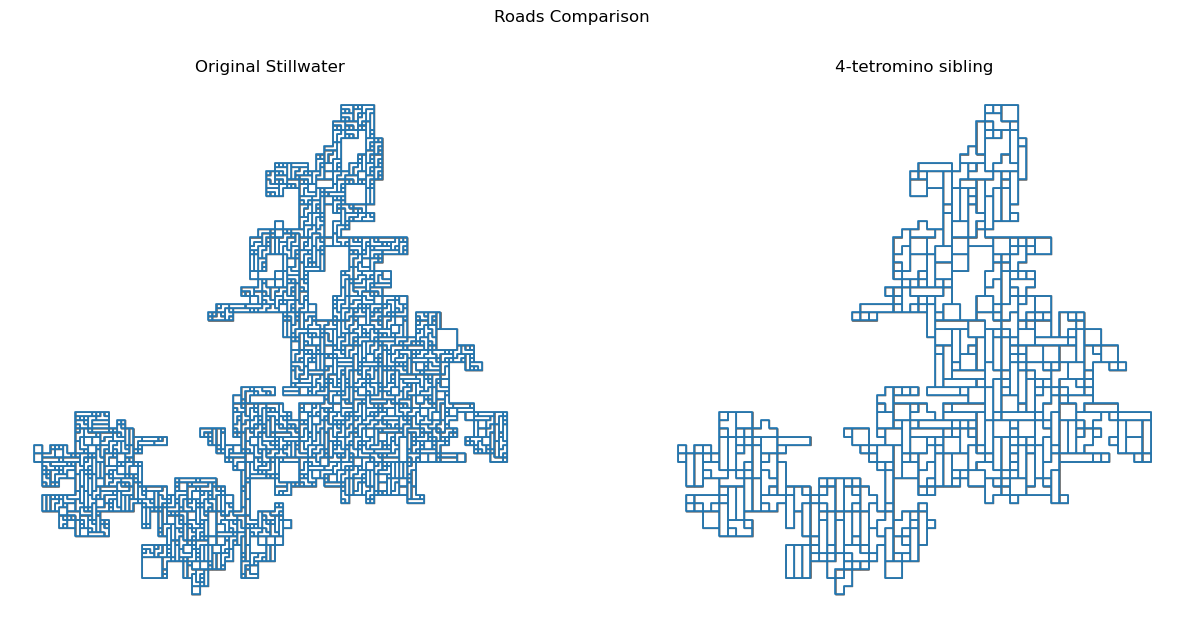

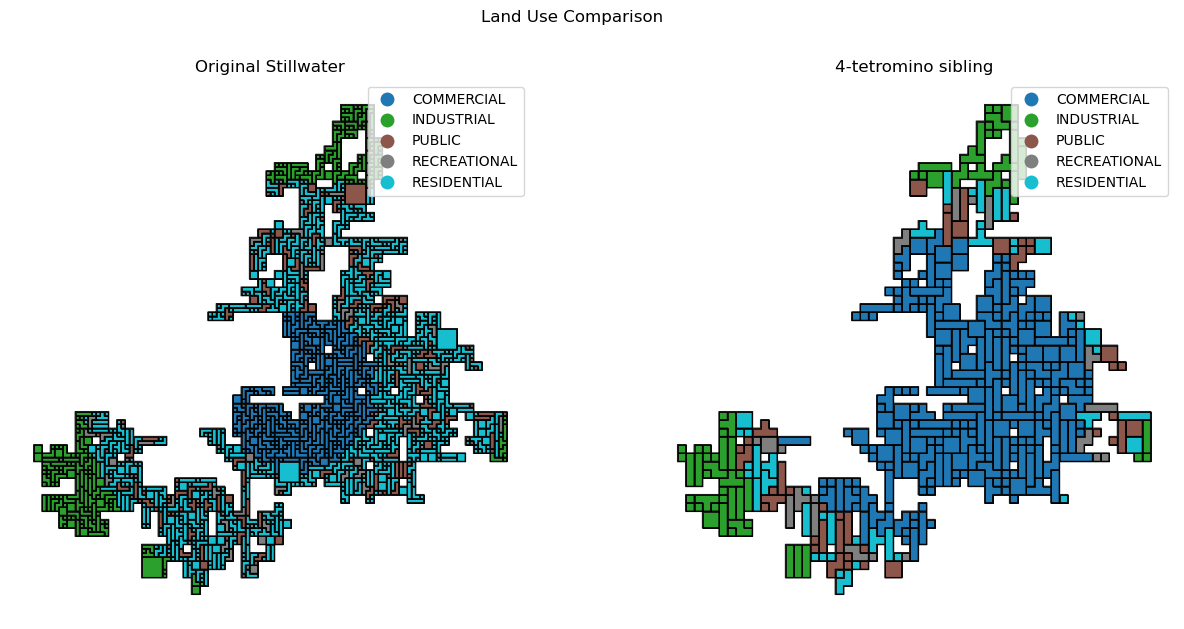

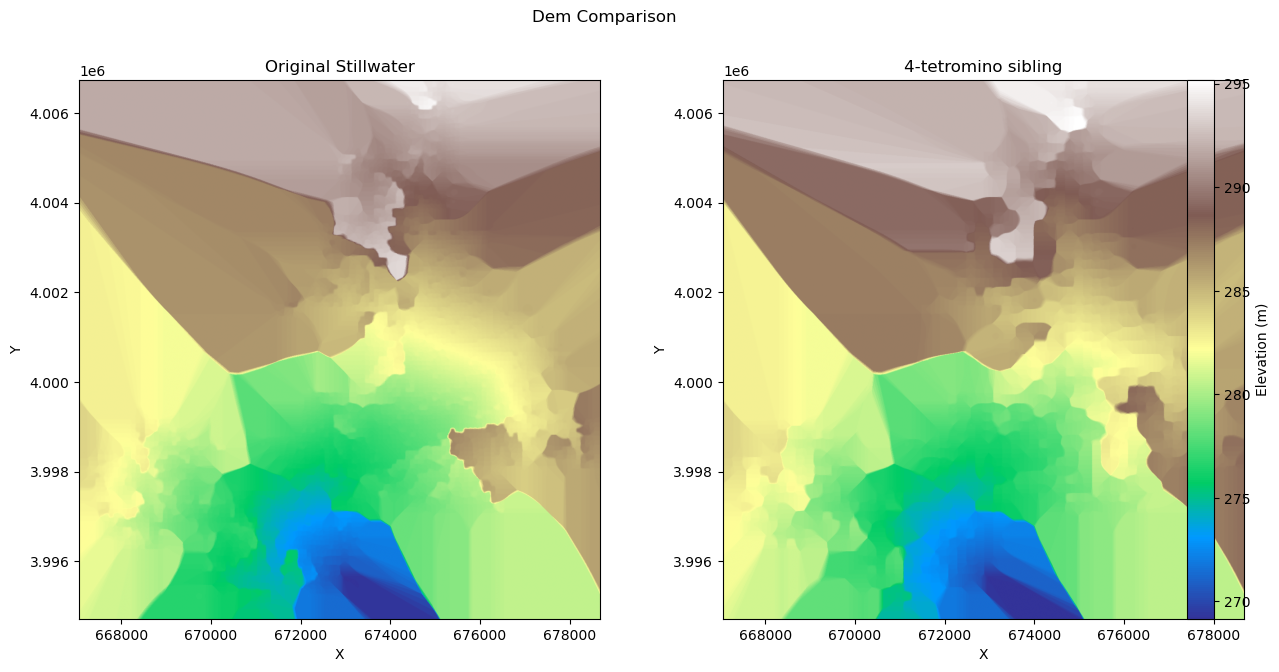

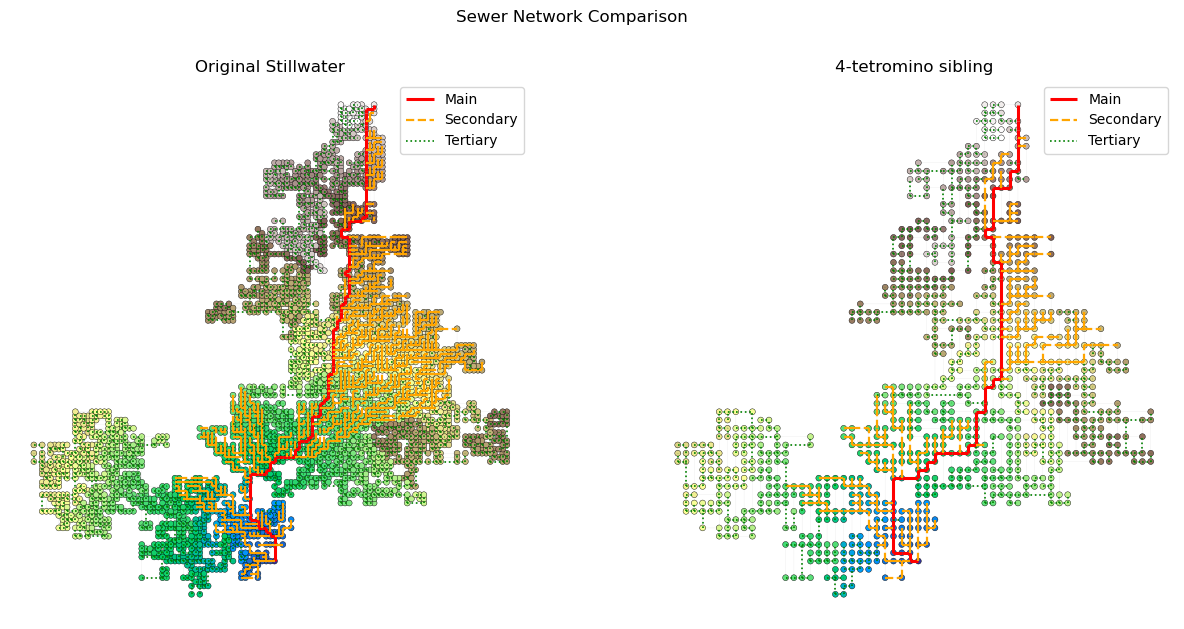

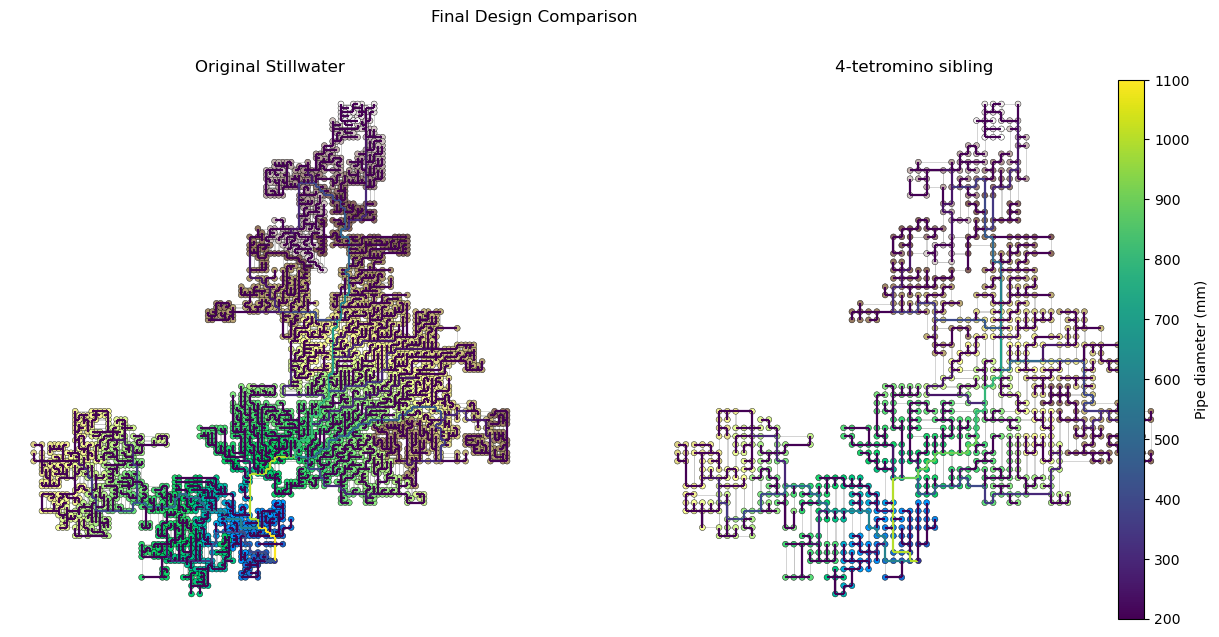

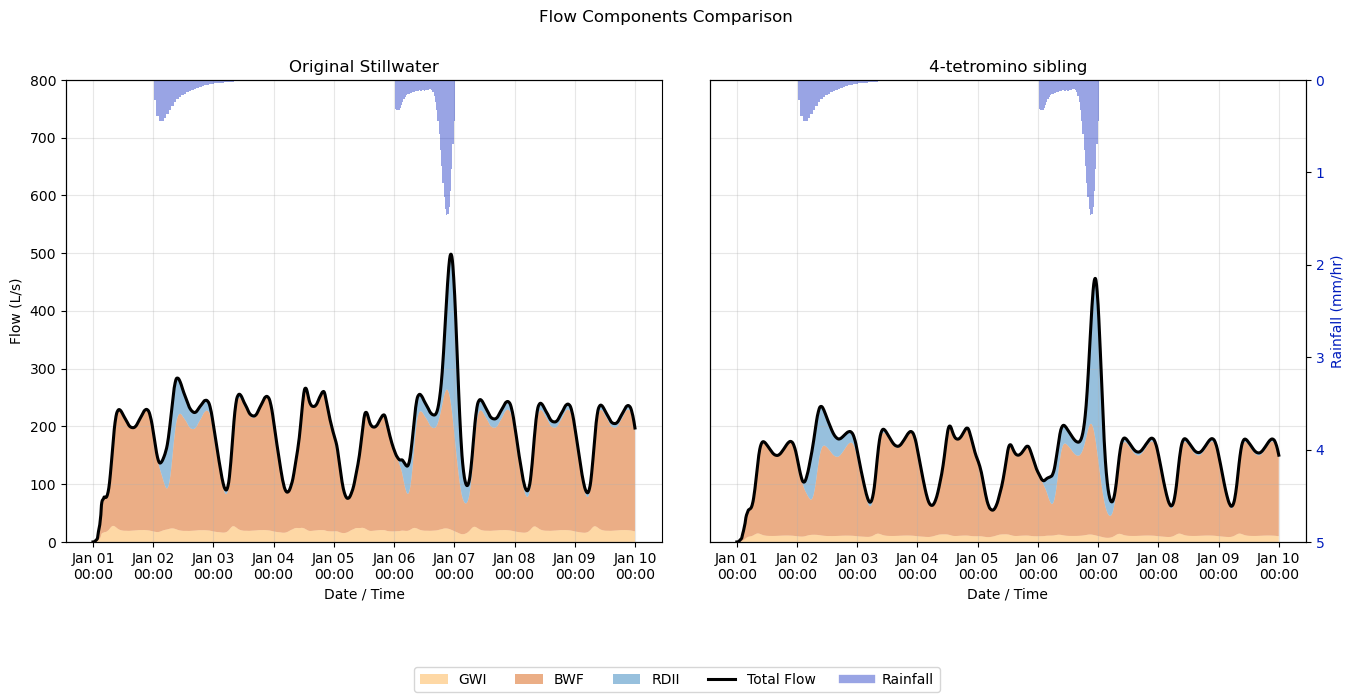

In [6]:
comparison_figures = st.plot_two_models(
    "all",
    base_project,
    project,
    labels=("Original Stillwater", "4-tetromino sibling"),
    scenario_name="bwf_gwi_rdii",
    start=start,
    end=end,
    figsize=(16, 7),
    diameter_field="diameter_mm",
    manhole_color_field="elevation",
    rain=rainfall_data,
    flow_min=0,
    flow_max=800,
    rain_min=0,
    rain_max=5
)
